In [1]:
# Imports
import arcpy
import os
import csv


# Input parameters
GeoDB = arcpy.GetParameterAsText(0) # The input geodatabase (Workspace)
DatasetTitle = arcpy.GetParameterAsText(1) # The output geodatabase
Attribution = arcpy.GetParameterAsText(2) # Attribution (citation) for the dataset
Abstract = arcpy.GetParameterAsText(3) # Abstract
TermsOfUse = arcpy.GetParameterAsText(4) # Terms of use. Non-sensitive government data is public domain
DatasetContact = arcpy.GetParameterAsText(5) # Contact for the dataset
Delimiter = arcpy.GetParameterAsText(6) # Fields delimiter. A pipe was chosen to avoid ambiguity with the commas in the WKT geometry data. You can change it back to a comma or whatever you want here.

# set the workspace
arcpy.env.workspace = GeoDB

In [2]:
# One goal of long term ecosystem monitoring programs is to preserve data in non-proprietary human and machine readable ASCII text file formats. Additionally, the U.S. government requires non-sensitive data to be publicly available in human and machine readable formats (see https://project-open-data.cio.gov/).
# ESRI geodatabases are highly functional for day to day use but are highly likely to be unsupported/unreadable decades in the future and do not meet open data requirements. The GeoDBToText tool prevents data loss by exporting each feature class in an ESRI personal geodatabase (.mdb) to human and machine text (pipe separated values/WKT, ESRI JSON) file formats. Should the original geodatabase be unusable the text files generated by this tool should still be recoverable. The National Park Service Arctic and Central Alaska Inventory and Monitoring Networks archive proprietary geospatial datasets in tandem with human and machine readable text file formats.
# Written by Scott D. Miller, Data manager, National Park Service Arctic Network Inventory and Monitoring Program, Fairbanks, AK. https://www.nps.gov/im/arcn/index.htm

# Exports each featureclass in the submitted geodatabase to  human and machine readable text and JSON files.
# Export files are created in the same directory as the input geodatabase

#Written by Scott D. Miller
#National Park Service, Arctic and Central Alaska Inventory and Monitoring programs
#2019-06-15

# Imports
import arcpy
import os
import csv


# Input parameters
GeoDB = arcpy.GetParameterAsText(0) # The input geodatabase (Workspace)
DatasetTitle = arcpy.GetParameterAsText(1) # The output geodatabase
Attribution = arcpy.GetParameterAsText(2) # Attribution (citation) for the dataset
Abstract = arcpy.GetParameterAsText(3) # Abstract
TermsOfUse = arcpy.GetParameterAsText(4) # Terms of use. Non-sensitive government data is public domain
DatasetContact = arcpy.GetParameterAsText(5) # Contact for the dataset
Delimiter = arcpy.GetParameterAsText(6) # Fields delimiter. A pipe was chosen to avoid ambiguity with the commas in the WKT geometry data. You can change it back to a comma or whatever you want here.

# set the workspace
arcpy.env.workspace = GeoDB

# Function to export a featureclass as a json file
def ExportJSON(FeatureClass):
    try:
        # This will be the output json file
        JsonFile = os.path.dirname(arcpy.env.workspace) + '\\' + FeatureClass + '.json'
        
        # If the json file exists already then delete it 
        if os.path.exists(JsonFile):
            arcpy.AddMessage("File exists: " + JsonFile + '. Deleted')
            os.remove(JsonFile)

        # Export the FeatureClass
        arcpy.AddMessage("Exporting " + JsonFile)
        arcpy.FeaturesToJSON_conversion(FeatureClass, JsonFile, "NOT_FORMATTED")
    except Exception as e:
        arcpy.AddMessage('Export failed for FeatureClass: ' + FeatureClass + ' ' + str(e))

# Function to export a featureclass as a comma separated values text file
def ExportCSV(FeatureClass, output_path):
    try:
   
        # This will be the output CSV file
        #CSVFile = os.path.dirname(arcpy.env.workspace) + '/' + FeatureClass + '.csv'
        CSVFilePath = os.path.join(output_path, FeatureClass + ".csv")
        CSVFile = open(CSVFilePath, 'a', newline='', encoding='utf-8')

        # if the CSV file exists already then delete it 
        if os.path.exists(CSVFile):
            arcpy.AddMessage("File exists: " + CSVFile + '. Deleted')
            os.remove(CSVFile)
        CSVFile = open(CSVFile,'a')  
        
        # Get the field names into the first row of the CSV file
        fields = arcpy.ListFields(FeatureClass)
        field_names =  [field.name for field in fields]
        field_names.insert(0,"Shape@WKT")
        FieldNames = ""
        for Field in field_names:
            FieldNames = FieldNames + Delimiter + Field
        
        # Add some metadata to the file
        CSVFile.write(DatasetTitle + "\n")
        CSVFile.write(Abstract + "\n")
        CSVFile.write(Attribution + "\n")
        CSVFile.write("Spatial reference: " + arcpy.Describe(FeatureClass).spatialReference.exportToString()  + "\n")
        CSVFile.write(TermsOfUse + "\n")
        CSVFile.write("This file is a human and machine readable equivalent of the layer " + FeatureClass + " exported from the ESRI personal geodatabase " + os.path.basename(GeoDB) + " and was generated to back up and archive the parent dataset for posterity in a non-proprietary text format in case the parent geodatabase format should become unsupported or outmoded. This file was not intended for day to day analytical work. Where possibe use the parent geodatabase.\n")
        CSVFile.write("Dataset contact: " + DatasetContact + " \n")
        CSVFile.write("Note: Row field values are separated by a pipe character | to avoid software confusion with the commas commonly found in WKT representations of geometry.")
        CSVFile.write("\n")

        # remove the leftmost delimiter and write the data line to the file
        CSVFile.write(FieldNames.lstrip(FieldNames[:1]) + '\n')

        # loop through the data rows and output to CSV
    #     for row in arcpy.da.SearchCursor(FeatureClass,field_names):
    #         i = 0
    #         while i < len(fields):
    #             CSVFile.write(str(row[i]) + Delimiter)
    #             i += 1
    #         CSVFile.write('\n')
    #     del row
    #     CSVFile.close()

        with arcpy.da.SearchCursor(FeatureClass, field_names) as cursor:
            for row in cursor:
                CSVFile.write(Delimiter.join([str(v) for v in row]) + "\n")

    except Exception as e:
        arcpy.AddMessage('Export failed for FeatureClass: ' + FeatureClass + ' ' + str(e))


# loop through all the feature classes in the geodatabase and export them to json files
try:
    FeatureClasses = arcpy.ListFeatureClasses()
    for FeatureClass in FeatureClasses:
        arcpy.AddMessage("Processing " + FeatureClass)
        ExportCSV(FeatureClass)
        ExportJSON(FeatureClass)
except Exception as e:
    arcpy.AddMessage('Error: ' + str(e))

### Checking this notebook is running in Pyhon environment with ArcGIS Pro license

In [3]:
# arcpy only works when ArcGIS is installed to the local computer
# must use the ArcGIS Pro Python environment.
# ArcGIS active license is required to run arcpy
import sys
print(sys.executable)

c:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\python.exe


In [4]:
import sys
print(sys.version)

3.13.7 | packaged by Anaconda, Inc. | (main, Sep 11 2025, 16:13:29) [MSC v.1938 64 bit (AMD64)]


In [5]:
import site
print(site.getsitepackages())

['c:\\Program Files\\ArcGIS\\Pro\\bin\\Python\\envs\\arcgispro-py3', 'c:\\Program Files\\ArcGIS\\Pro\\bin\\Python\\envs\\arcgispro-py3\\Lib\\site-packages']


In [6]:
import arcpy

### Testing the defined functions - CSV Conversion

In [7]:
print(os.getcwd())

y:\aa_GSS_Student_Engagement_Training\Sho\GeoDBToText


In [8]:
def ExportCSV(FeatureClass, output_path):
    try:
        CSVFilePath = os.path.join(output_path, FeatureClass + ".csv")

        # delete file if exists
        if os.path.exists(CSVFilePath):
            arcpy.AddMessage("File exists: " + CSVFilePath + ". Deleted")
            os.remove(CSVFilePath)

        # open file ONCE
        with open(CSVFilePath, "w", newline="", encoding="utf-8") as CSVFile:

            fields = arcpy.ListFields(FeatureClass)
            field_names = [f.name for f in fields]
            field_names.insert(0, "Shape@WKT")

            # metadata
            CSVFile.write(DatasetTitle + "\n")
            CSVFile.write(Abstract + "\n")
            CSVFile.write(Attribution + "\n")
            CSVFile.write("Spatial reference: " +
                          arcpy.Describe(FeatureClass).spatialReference.exportToString() + "\n")
            CSVFile.write(TermsOfUse + "\n")

            CSVFile.write("\n")

            # header
            CSVFile.write(Delimiter.join(field_names) + "\n")

            # data
            with arcpy.da.SearchCursor(FeatureClass, field_names) as cursor:
                for row in cursor:
                    CSVFile.write(Delimiter.join([str(v) for v in row]) + "\n")

    except Exception as e:
        arcpy.AddMessage("Export failed for FeatureClass: " +
                          FeatureClass + " " + str(e))

In [9]:
ExportCSV("Y:/aa_GSS_Student_Engagement_Training/Sho/GeoDBToText/data/winona_lake.shp", "./data/winona_lake.csv")

### GeoPandas for quick data inspection

#### Instaling GeoPandas

In [30]:
import sys
print(sys.executable)

c:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\python.exe


In [31]:
!pip show geopandas

Name: geopandas
Version: 1.1.3
Summary: Geographic pandas extensions
Home-page: 
Author: 
Author-email: Kelsey Jordahl <kjordahl@alum.mit.edu>
License: 
Location: C:\Users\gsssmu\AppData\Roaming\Python\Python313\site-packages
Requires: numpy, packaging, pandas, pyogrio, pyproj, shapely
Required-by: 


In [35]:
%pip install geopandas
%pip install contextily

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
   ------ --------------------------------- 5.2/30.1 MB 28.9 MB/s eta 0:00:01
   ------------- -------------------------- 10.5/30.1 MB 27.6 MB/s eta 0:00:01
   ---------------- ----------------------- 12.6/30.1 MB 20.2 MB/s eta 0:00:01
   ----------------------- ---------------- 17.8/30.1 MB 21.6 MB/s eta 0:00:01
   ------------------------------ --------- 23.1/30.1 MB 22.2 MB/s eta 0:00:01
   -------------------------------------- - 29.1/30.1 MB 22.8 MB/s eta 0:00:01
   ---------------------------------------- 30.1/30.1 MB 21.8 MB/s  0:00:01

   ---- -----------------------------------  1/10 [joblib]
   ---- -----------------------------------  1/10 [joblib]
   ------------ ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [38]:
import geopandas

import contextily
import matplotlib.pyplot as plt

#### Visual inspection of data with GeoPandas

In [43]:
w_lake = geopandas.read_file("./data/winona_lake.shp")
w_lake

,Id,geometry
0,0,"POLYGON ((346406.959 2347187.62, 346501.844 23..."
1,0,"POLYGON ((347586.808 2346889.881, 347677.704 2..."


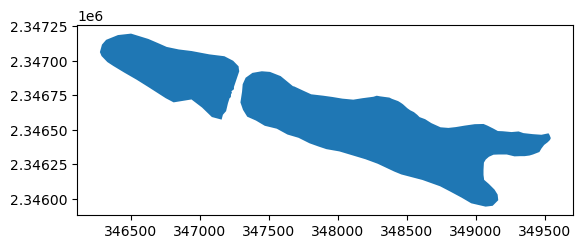

In [44]:
w_lake.plot()
plt.show()

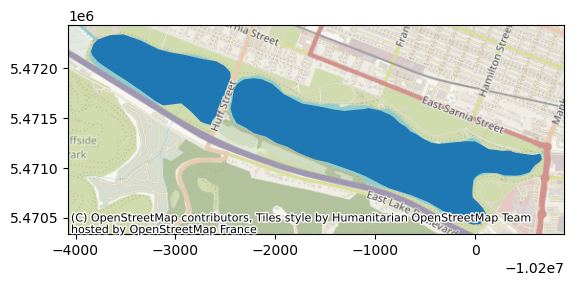

In [ ]:
#contextily requires Web Mercator (EPSG:3857)
w_lake = w_lake.to_crs(epsg=3857)

fig, ax = plt.subplots()
w_lake.geometry.plot(ax=ax, markersize=1)
contextily.add_basemap(ax)
plt.show()